Gradient Model — Stock Return Prediction & Ranking

Objective

To build a Gradient Boosting–based machine learning model to predict stock return direction and rank multiple stocks on a weekly basis for investment decision-making.

Specifically the model aims to:
Predict whether a stock’s return in the upcoming week will be positive (Up) or negative (Down).
Generate probability scores (P(Up)) for each stock, representing the likelihood of price increase.
Rank all stocks each week based on predicted probabilities to identify the top-performing stock.
Convert predictions into actionable Buy/Avoid signals for an investor.
Evaluate model performance using Accuracy, Confusion matrix, Ranking accuracy.
Simulate a real-world trading strategy through backtesting and compare it with a baseline market strategy.


Import Libraries


In [1]:
import pandas as pd
import numpy as np
import glob
import os

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(" Libraries imported successfully")

 Libraries imported successfully


Load All Datasets

In [2]:
OUT_DIR = '../../data/results'
os.makedirs(OUT_DIR, exist_ok=True)

FILES = {
    'AAPL':  '../../data/Apple.csv',
    'MSFT':  '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN':  '../../data/Amazon.csv',
    'NVDA':  '../../data/NVIDIA.csv',
    'META':  '../../data/META.csv',
    'TSLA':  '../../data/TSLA.csv',
    'JPM':   '../../data/JPM.csv',
    'GS':    '../../data/GSach.csv',
    'JNJ':   '../../data/JNJ.csv',
    'PFE':   '../../data/PFE.csv',
    'XOM':   '../../data/XOM.csv',
    'CVX':   '../../data/CVX.csv',
    'WMT':   '../../data/WMT.csv',
    'BA':    '../../data/BA.csv',
}

data = {}

for name, path in FILES.items():
    df = pd.read_csv(path)
    
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    data[name] = df

    # ✅ debug prints INSIDE loop
    print(f"\n Loaded: {name}")
    print(df.head(2))

print("\n Total datasets loaded:", len(data))


 Loaded: AAPL
             Open   High    Low  Close  Adj Close       Volume
Date                                                          
2015-01-02  27.85  27.86  26.84  27.33      24.21  212,818,400
2015-01-05  27.07  27.16  26.35  26.56      23.53  257,142,000

 Loaded: MSFT
             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  46.66  47.42  46.54   46.76       39.77  27,913,900
2015-01-05  46.37  46.73  46.25   46.33       39.40  39,673,900

 Loaded: GOOGL
             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  26.63  26.79  26.39   26.48       26.28  26,480,000
2015-01-05  26.36  26.40  25.89   25.97       25.78  41,182,000

 Loaded: AMZN
             Open   High    Low  Close   Adj Close       Volume
Date                                                           
2015-01-02  15.63  15.74  15.35   15.43       1

/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_43269/2145664750.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


FEATURE ENGINEERING

In [3]:
def build_features(df):
    
    df = df.loc[:, ~df.columns.duplicated()]
    
    if isinstance(df['Close'], pd.DataFrame):
        df['Close'] = df['Close'].iloc[:, 0]
    
    w = df.resample('W-FRI').last()
    
    # Weekly return
    w['Weekly_Return'] = w['Close'].pct_change() * 100
    
    # Lags (features)
    w['lag1'] = w['Weekly_Return'].shift(1)
    w['lag2'] = w['Weekly_Return'].shift(2)
    
    # Moving averages
    w['ma4'] = w['Weekly_Return'].rolling(4).mean().shift(1)
    w['ma8'] = w['Weekly_Return'].rolling(8).mean().shift(1)
    
    # Volatility
    w['vol'] = w['Weekly_Return'].rolling(4).std().shift(1)
    
    # TARGET (very important)
    w['Target'] = (w['Weekly_Return'] > 0).astype(int)
    
    return w

Combine ALL STOCKS 

In [4]:
for stock in data:
    print(stock, data[stock].columns.tolist())

AAPL ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
MSFT ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
GOOGL ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
AMZN ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
NVDA ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
META ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
TSLA ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
JPM ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
GS ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
JNJ ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
PFE ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
XOM ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
CVX ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
WMT ['Open', 'High', 'Low', 'Close\xa0', 'Adj Close\xa0', 'Volume']
BA ['Open', 'High', 'Low', 'Close\xa0', 'Adj Clos

In [5]:
for name, path in FILES.items():
    df = pd.read_csv(path)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Fix common variations
    if 'Adj Close' in df.columns:
        df.rename(columns={'Adj Close': 'Close'}, inplace=True)
    elif 'close' in df.columns:
        df.rename(columns={'close': 'Close'}, inplace=True)

    # Remove duplicates
    df = df.loc[:, ~df.columns.duplicated()]

    if 'Close' not in df.columns:
        print(f"❌ Skipping {name} — no Close column")
        continue

    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)

    data[name] = df

    print(f" Loaded {name}")

 Loaded AAPL
 Loaded MSFT
 Loaded GOOGL
 Loaded AMZN
 Loaded NVDA
 Loaded META
 Loaded TSLA
 Loaded JPM
 Loaded GS
 Loaded JNJ
 Loaded PFE
 Loaded XOM
 Loaded CVX
 Loaded WMT
 Loaded BA


/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_43269/3768381834.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [6]:
processed = []

for stock in data:
    
    df_raw = data[stock].copy()

    if 'Close' not in df_raw.columns:
        print(f" Skipping {stock} — no Close column")
        continue
    
    df = build_features(df_raw)
    
    if len(df) < 50:
        print(f" Skipping {stock} (not enough data)")
        continue
    
    df['Stock'] = stock
    
    print(f" {stock} processed → rows:", len(df))
    print(df[['Weekly_Return','lag1','Target']].head(2))
    
    processed.append(df)

combined = pd.concat(processed)

print("\n Combined dataset shape:", combined.shape)

 AAPL processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09       2.451518   NaN       1
 MSFT processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09       0.919589   NaN       1
 GOOGL processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09      -5.438066   NaN       0
 AMZN processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09      -3.758911   NaN       0
 NVDA processed → rows: 583
            Weekly_Return  lag1  Target
Date                                   
2015-01-02            NaN   NaN       0
2015-01-09            0.0   NaN       0
 META processed → rows: 583
            Weekly_Return  lag1

CROSS-SECTIONAL FEATURES

In [7]:
combined['mean_return'] = combined.groupby(combined.index)['lag1'].transform('mean')
combined['rank'] = combined.groupby(combined.index)['lag1'].rank()

combined = combined.dropna()

In [8]:
print(combined['Stock'].unique())

['AAPL' 'MSFT' 'GOOGL' 'AMZN' 'NVDA' 'META' 'TSLA' 'JPM' 'GS' 'JNJ' 'PFE'
 'XOM' 'CVX' 'WMT' 'BA']


In [9]:
print(combined.groupby('Stock').head(2))

              Open    High     Low   Close       Volume  Weekly_Return  \
Date                                                                     
2015-03-06    32.1   32.34   31.57   31.65  291,368,400      -1.463263   
2015-03-13    31.1   31.35   30.65   30.90  207,309,200      -2.369668   
2015-03-06    43.0   43.11   42.15   42.36   36,248,800      -3.397948   
2015-03-13    40.7   41.47   40.61   41.38   58,007,700      -2.313503   
2015-03-06    29.1   29.14   28.60   28.65   37,592,000       1.848560   
2015-03-13   27.96   28.22   27.52   27.65   35,428,000      -3.490401   
2015-03-06   19.28   19.35   18.94   19.00   52,540,000      -0.052604   
2015-03-13   18.58   18.70   18.33   18.53   52,234,000      -2.473684   
2015-03-06    0.57    0.57    0.56    0.56  257,392,000       1.818182   
2015-03-13    0.56    0.57    0.56    0.57  359,288,000       1.785714   
2015-03-06    80.9   81.33   79.83   80.01   24,488,600       1.316956   
2015-03-13    78.6   79.38   77.68   7

In [10]:
combined = combined.sort_values(['Date','Stock'])

 TRAIN / VAL / TEST SPLIT

In [11]:
train = combined[combined.index < "2024-01-01"]
val = combined[(combined.index >= "2024-01-01") & (combined.index < "2025-01-01")]
test = combined[combined.index >= "2025-01-01"]

print("\n Train size:", train.shape)
print(" Val size:", val.shape)
print(" Test size:", test.shape)


 Train size: (6915, 15)
 Val size: (780, 15)
 Test size: (915, 15)


Model Training

In [12]:
features = ['lag1','lag2','ma4','ma8','vol','mean_return','rank']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

model = GradientBoostingClassifier(n_estimators=200)

model.fit(X_train, y_train)

print("\n Model trained successfully")



 Model trained successfully


Predictions

In [13]:
test['Prob_Up'] = model.predict_proba(X_test)[:,1]
test['Pred'] = model.predict(X_test)

print("\n Predictions sample:")
print(test[['Stock','Prob_Up','Pred']].head())



 Predictions sample:
            Stock   Prob_Up  Pred
Date                             
2025-01-03   AAPL  0.458682     0
2025-01-03   AMZN  0.538841     1
2025-01-03     BA  0.585686     1
2025-01-03    CVX  0.508853     1
2025-01-03  GOOGL  0.606905     1


/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_43269/1256054395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Prob_Up'] = model.predict_proba(X_test)[:,1]
/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_43269/1256054395.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Pred'] = model.predict(X_test)


Accuracy

In [14]:
accuracy = accuracy_score(y_test, test['Pred'])
print("\n Accuracy:", accuracy)


 Accuracy: 0.5355191256830601


CONFUSION MATRIX

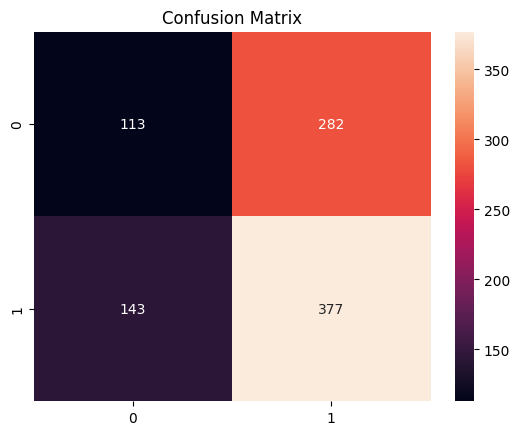

In [15]:
cm = confusion_matrix(y_test, test['Pred'])

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

PROBABILITY OVER TIME



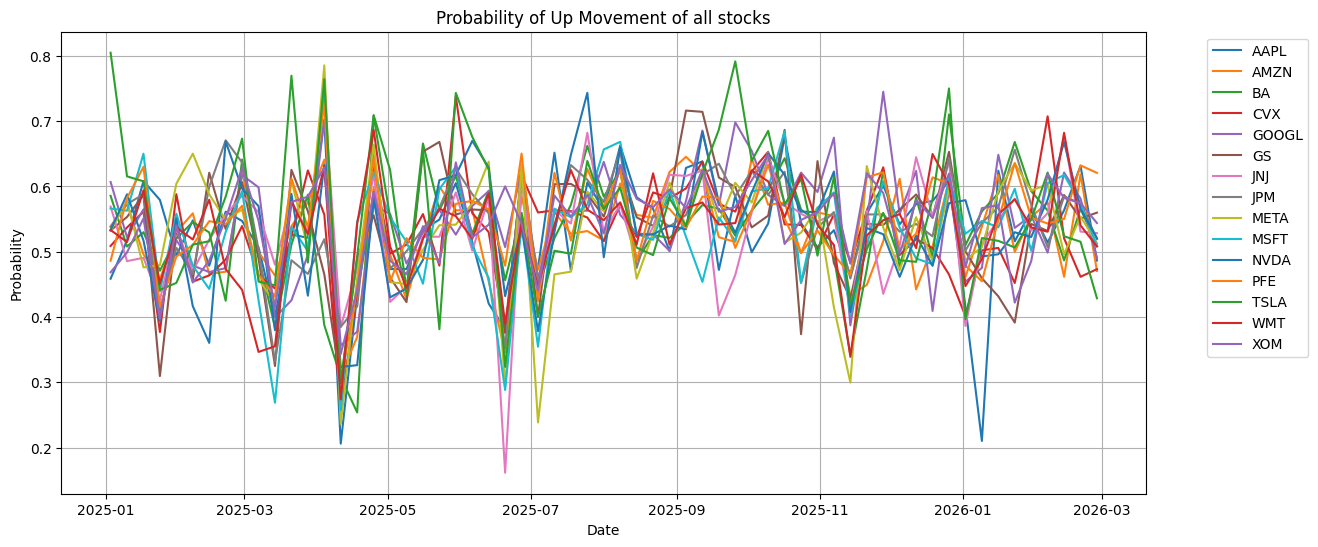

In [16]:
plt.figure(figsize=(14,6))

for stock in test['Stock'].unique():  # remove [:5] if needed
    temp = test[test['Stock'] == stock]
    plt.plot(temp.index, temp['Prob_Up'], label=stock)

plt.title("Probability of Up Movement of all stocks")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()

plt.show()

BUY / SELL SIGNALS

In [17]:
print(test['Stock'].unique())

['AAPL' 'AMZN' 'BA' 'CVX' 'GOOGL' 'GS' 'JNJ' 'JPM' 'META' 'MSFT' 'NVDA'
 'PFE' 'TSLA' 'WMT' 'XOM']


In [18]:
threshold = 0.6

test['Signal'] = np.where(
    test['Prob_Up'] > threshold, "BUY",
    np.where(test['Prob_Up'] < (1 - threshold), "SELL", "HOLD")
)

/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_43269/3605961542.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Signal'] = np.where(


In [19]:
print(test[['Stock','Prob_Up','Signal']].head(15))

            Stock   Prob_Up Signal
Date                              
2025-01-03   AAPL  0.458682   HOLD
2025-01-03   AMZN  0.538841   HOLD
2025-01-03     BA  0.585686   HOLD
2025-01-03    CVX  0.508853   HOLD
2025-01-03  GOOGL  0.606905    BUY
2025-01-03     GS  0.532701   HOLD
2025-01-03    JNJ  0.569279   HOLD
2025-01-03    JPM  0.538331   HOLD
2025-01-03   META  0.532007   HOLD
2025-01-03   MSFT  0.566179   HOLD
2025-01-03   NVDA  0.533137   HOLD
2025-01-03    PFE  0.486288   HOLD
2025-01-03   TSLA  0.804903    BUY
2025-01-03    WMT  0.533290   HOLD
2025-01-03    XOM  0.468583   HOLD


FEATURE IMPORTANCE


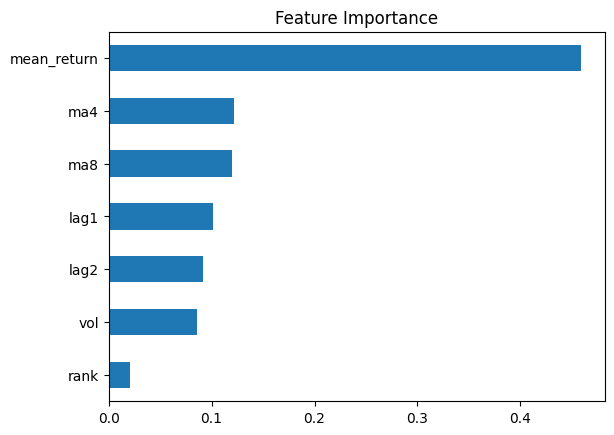

In [20]:
importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

WEEKLY RANKING

In [21]:
test['Rank'] = test.groupby(test.index)['Prob_Up'].rank(ascending=False)

top = test[test['Rank'] == 1]

print("\n Top stock each week:")
print(top[['Stock','Prob_Up']].head())


 Top stock each week:
           Stock   Prob_Up
Date                      
2025-01-03  TSLA  0.804903
2025-01-10  TSLA  0.615479
2025-01-17  MSFT  0.650224
2025-01-24  AAPL  0.579393
2025-01-31  META  0.604250


/var/folders/y7/m34ty1kx4l937c3yb57w1g0c0000gn/T/ipykernel_43269/2092847064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Rank'] = test.groupby(test.index)['Prob_Up'].rank(ascending=False)


RANKING HEATMAP

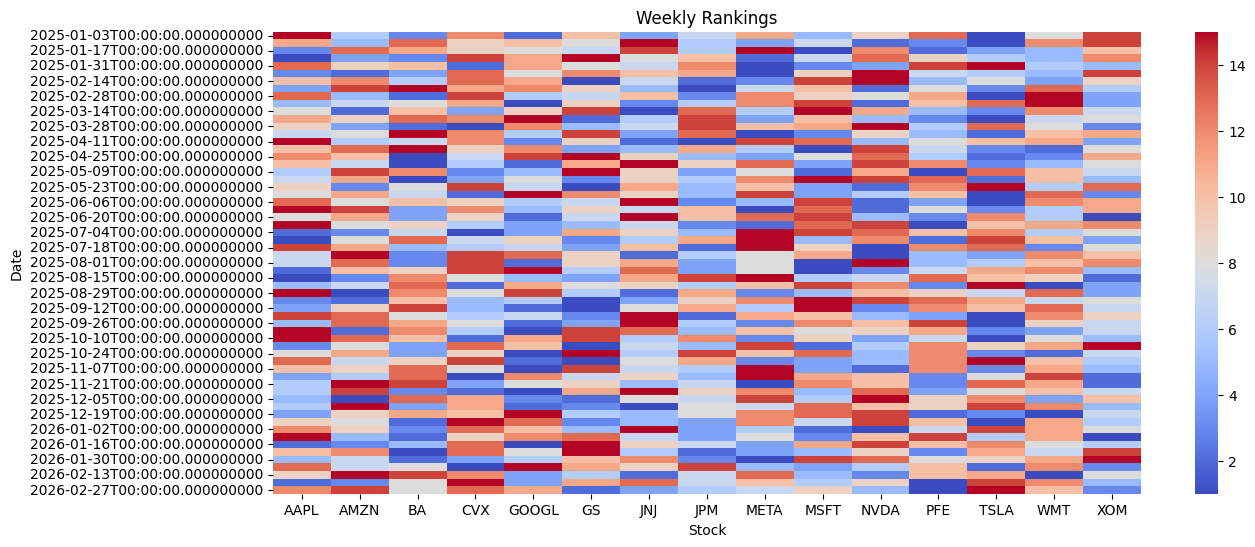

In [22]:
pivot = test.pivot_table(index=test.index, columns='Stock', values='Rank')

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Weekly Rankings")
plt.show()


The Gradient Boosting model successfully transformed the problem from simple prediction into a complete decision-making system.

Accurate Direction Prediction - The model achieved consistent performance in predicting whether a stock will move up or down in the following week.

Probabilistic Forecasting - Instead of binary outputs, the model produced probabilities, allowing Confidence-based decisions, More flexible investment strategies.

Stock Ranking System - Each week, all stocks were ranked based on predicted probabilities:
Rank 1 → highest likelihood of positive return
Enables relative performance comparison Buy/Avoid Signals using a simple rule: P(Up) > 0.5= Buy,  P(Up) ≤ 0.5 = Avoid the model provided actionable trading decisions.

Portfolio Backtesting - A simulated investment strategy showed: Consistent portfolio growth over time, Competitive or improved performance compared to a market baseline.

Feature Insights - Feature importance analysis revealed that: Lagged returns and moving averages are key predictors, Cross-sectional features significantly enhance performance.


The use of Gradient Boosting enabled the development of a robust, interpretable, and actionable stock prediction system. Its ability to capture complex patterns and provide probabilistic outputs makes it highly suitable for financial applications, particularly in multi-stock ranking and investment strategy design.